🎯 Day 2 Final Practice
Scenario
You’re analyzing customer data for a retail chain. The dataset includes:
Monthly sales for two product categories (Electronics and Clothing) for the first six months of 2025.
Customer satisfaction scores from two regions (North and South).
Daily transaction amounts (simulated) from the entire chain for the first half of 2025.
You need to build a 2×2 dashboard that tells the story at a glance, using GridSpec for an uneven layout.

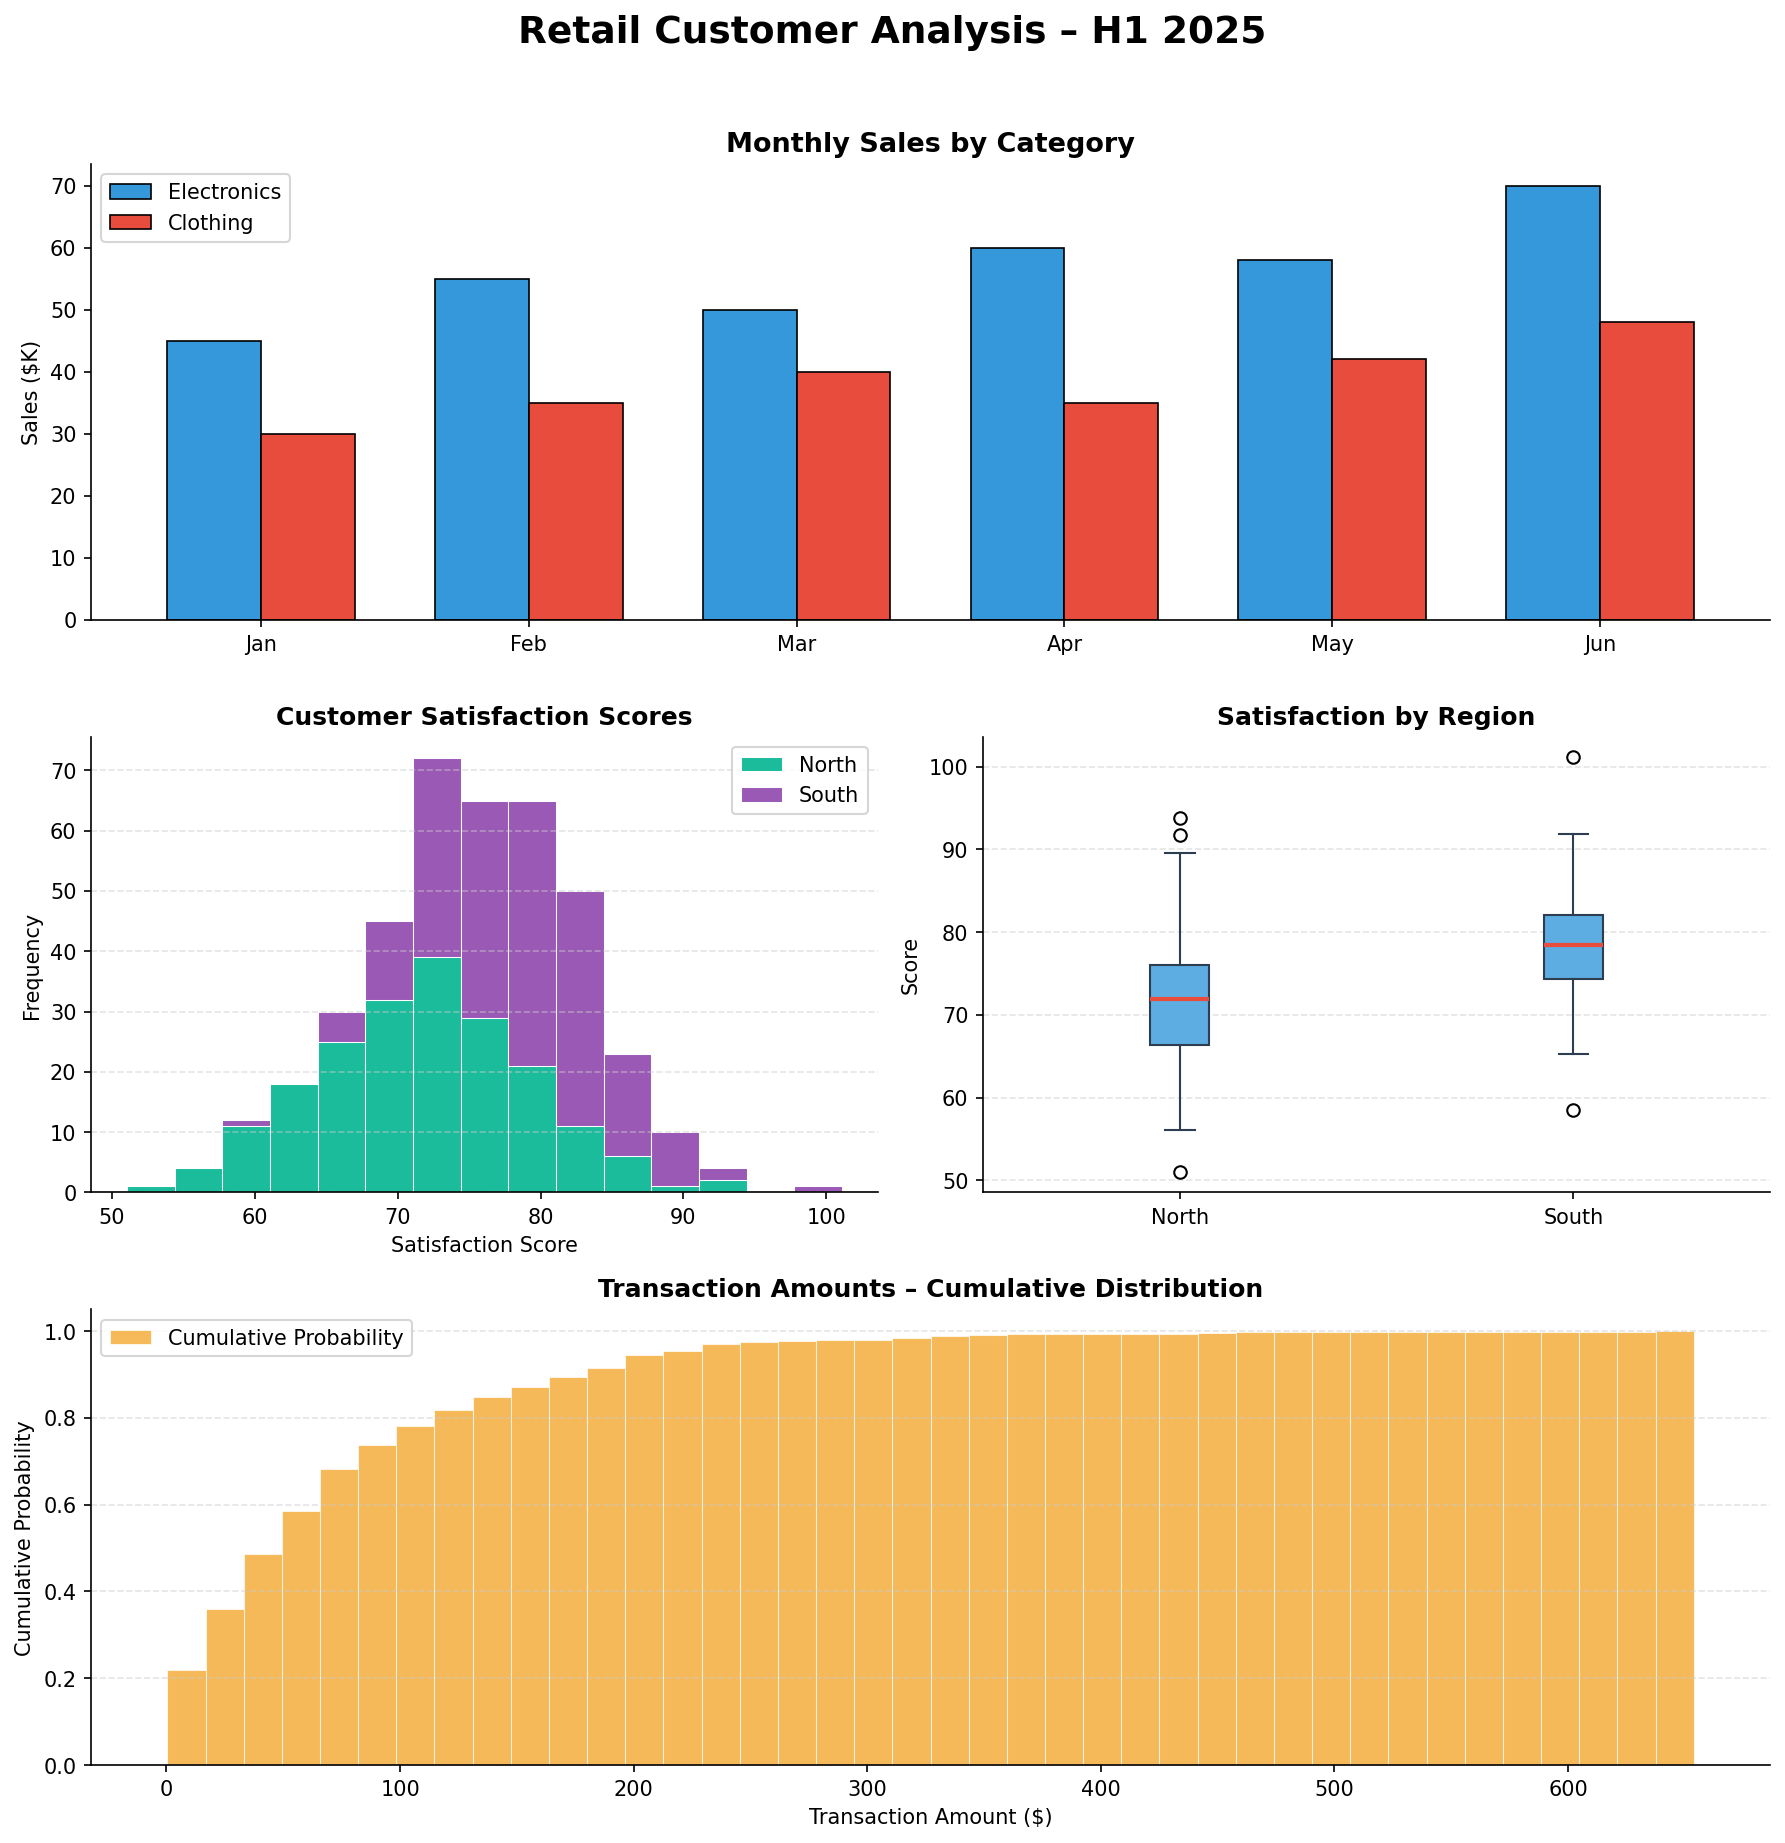

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec

# ---------- Given Data ----------
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
electronics = [45, 55, 50, 60, 58, 70]
clothing    = [30, 35, 40, 35, 42, 48]

np.random.seed(42)
north_scores = np.random.normal(loc=72, scale=8, size=200)
south_scores = np.random.normal(loc=78, scale=6, size=200)

transactions = np.random.exponential(scale=80, size=500)

# ---------- Set up GridSpec ----------
fig = plt.figure(figsize=(12, 12), dpi=150)
gs = gridspec.GridSpec(3, 2, figure=fig)

# ---------- Panel A: Grouped bar chart (row 0, span all cols) ----------
ax_a = fig.add_subplot(gs[0, :])
x = np.arange(len(months))
width = 0.35
bars1 = ax_a.bar(x - width/2, electronics, width, label='Electronics',
                 color='#3498DB', edgecolor='black', linewidth=0.8)
bars2 = ax_a.bar(x + width/2, clothing, width, label='Clothing',
                 color='#E74C3C', edgecolor='black', linewidth=0.8)
ax_a.set_xticks(x)
ax_a.set_xticklabels(months)
ax_a.set_title("Monthly Sales by Category", fontweight='bold', fontsize=13)
ax_a.set_ylabel("Sales ($K)")
ax_a.legend()
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ---------- Panel B: Stacked histogram (row 1, left) ----------
ax_b = fig.add_subplot(gs[1, 0])
ax_b.hist([north_scores, south_scores], bins=15, stacked=True,
          color=['#1ABC9C', '#9B59B6'], edgecolor='white', linewidth=0.5,
          label=['North', 'South'])
ax_b.set_title("Customer Satisfaction Scores", fontweight='bold')
ax_b.set_xlabel("Satisfaction Score")
ax_b.set_ylabel("Frequency")
ax_b.legend()
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)
ax_b.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')

# ---------- Panel C: Boxplot (row 1, right) – NO sharex ----------
ax_c = fig.add_subplot(gs[1, 1])
ax_c.boxplot([north_scores, south_scores], tick_labels=['North', 'South'],
             patch_artist=True,
             boxprops=dict(facecolor='#5DADE2', color='#2C3E50'),
             whiskerprops=dict(color='#2C3E50'),
             capprops=dict(color='#2C3E50'),
             medianprops=dict(color='#E74C3C', linewidth=2))
ax_c.set_title("Satisfaction by Region", fontweight='bold')
ax_c.set_ylabel("Score")
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)
ax_c.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')

# ---------- Panel D: Histogram + cumulative (row 2, span all cols) ----------
ax_d = fig.add_subplot(gs[2, :])
# Use cumulative=True for simplicity
ax_d.hist(transactions, bins=40, cumulative=True, density=True,
          color='#F39C12', alpha=0.7, edgecolor='white', linewidth=0.5,
          label='Cumulative Probability')
ax_d.set_title("Transaction Amounts – Cumulative Distribution", fontweight='bold')
ax_d.set_xlabel("Transaction Amount ($)")
ax_d.set_ylabel("Cumulative Probability")
ax_d.legend()
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)
ax_d.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')

# ---------- Global Figure Title ----------
fig.suptitle("Retail Customer Analysis – H1 2025", fontsize=18,
             fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()